# Clase 36 - Notebook 1 - Simulación del modelo de balances de masa y energía

El modelo del secador por aspersión consiste de un sistema de ecuaciones diferenciales más ecuaciones algebraicas. A este subsistema se le denomina sistema de ecuaciones diferenciales algebraicas o DAE.

El comando ls le permite ver si se encuentra en el directorio correcto. La carpeta `spraydrylib` junto a sus archivos debería ser visible:

# Modelo de Ecuaciones Diferenciales Algebraicas (DAE) del Secador Spray

Este documento describe el modelo matemático implementado en `model_casadi.py`, incluyendo todas las constantes, propiedades físicas, ecuaciones algebraicas y ecuaciones diferenciales.

---

## Variables de estado

- $ H_o(t) $: Humedad de salida del aire (kg vapor / kg aire seco)  
- $ X_o(t) $: Contenido de humedad de la partícula (kg agua / kg sólidos secos)  
- $ T_4(t) $: Temperatura del aire de salida (K)  
- $ r_d(t) $: Radio de la gota (m) [variable algebraica]

---

## Parámetros del modelo

- $ G $: Flujo másico de aire seco (kg/s)  
- $ T_i $: Temperatura del aire de entrada (K)  
- $ H_i $: Humedad del aire de entrada (kg vapor / kg aire seco)  
- $ F $: Flujo másico de sólidos secos (kg/s)  
- $ T_F $: Temperatura de alimentación de sólidos (K)  
- $ X_i $: Contenido inicial de humedad en el sólido (kg agua / kg sólidos secos)  
- $ r_i $: Radio inicial de la gota (m)  

---

## Constantes empíricas y propiedades

- $ A_{EMP} = 1000.0 $  
- $ B_{EMP} = 290.0 $  
- $ Nu = 2.0 $: Número de Nusselt adimensional  
- $ m_{equil} = 1.5 $: Factor de equilibrio de humedad  
- $ M_A = 7.0 $: Masa de aire dentro del secador (kg)  
- $ T_{sat} = 316.15 \,\text{K} $: Temperatura de saturación (43°C)  
- $ X_{oc} = 0.25 $: Contenido crítico de humedad en el sólido  

---

## Relaciones auxiliares

Masa seca equivalente de la gota:

$$
m_s = \frac{r_i^3 \, 4\pi \, (A_{EMP}(1+X_i)+B_{EMP})}{3(1+X_i)^2}
$$

Radio en función de la humedad del sólido:

$$
r(X) = \left(\frac{3 (1+X)^2 \, m_s}{4\pi (A_{EMP}(1+X)+B_{EMP})}\right)^{1/3}
$$

---

## Propiedades dependientes de $ T $ y $ H $

- Conductividad térmica del aire:
$$
k_A(T) = 7.4\times 10^{-8}\,T + 4.19\times 10^{-6}
$$

- Difusividad efectiva de agua en aire:
$$
D_e(T) = 1.38\times 10^{-11}\,T - 1.55\times 10^{-9}
$$

- Calor latente de vaporización:
$$
\lambda_{sat}(T) = 3180.14 - 2.508\,T
$$

- Capacidad calorífica del aire húmedo de entrada:
$$
c_{p,in}(T) = \frac{3774.48 + 1.15(T-273.15) + 3.93\times 10^{-3}(T-273.15)^2}{1000}
$$

- Capacidad calorífica del aire húmedo en función de la humedad del aire:
$$
c_p(H) = 1.005 + 1.88H
$$

- Calor específico a volumen constante:
$$
c_v(H) = 0.718 + 1.4108H
$$

---
## Ecuación algebraica

$$
r_d - r(X) = 0
$$

con transición a $ X_{oc} $.

---

## Ecuaciones diferenciales (DAE)

1. **Evolución de humedad de salida del aire**

$$\frac{dH_o}{dt} = \frac{G}{M_A}(H_i - H_o) + \frac{F}{M_A}(X_i - X_o)$$

2. **Evolución de contenido de humedad en el sólido**

$$
\frac{dX_o}{dt} =
\begin{cases}
\dfrac{h}{\lambda_{sat}} \dfrac{A_{drop}}{m_s} (T_{sat} - T_4), & X_o \geq X_{oc} \\[1.0em]
-\dfrac{4\pi^2}{(2r_d)^2} D_e (X_o - m_{equil}H_o), & X_o < X_{oc}
\end{cases}
$$

3. **Evolución de la temperatura del aire de salida**

$$
\frac{dT_4}{dt} =
\frac{ F_1 c_{p,in}(T_{sat})(T_F - T_{sat}) + F_3 c_p(T_i, H_i)(T_i - T_{sat})
- F_4 c_p(T_4,H_o)(T_4 - T_{sat}) + \lambda_{sat}(T_{sat})(F_3 y_{v,3} - F_4 y_{v,4})}
{M_g c_v(H_o)}
$$

donde:

$$
\begin{aligned}
F_1 &= F(1+X_i) \\
F_3 &= G(1+H_i) \\
F_4 &= G(1+H_o) \\
y_{v,3} &= \frac{H_i}{1-H_i} \\
y_{v,4} &= \frac{H_o}{1-H_o} \\
M_g &= M_A(1+H_o)
\end{aligned}
$$

---

# 01 — Modelo básico

Ejecuta **una** simulación y grafica:
- Humedad y temperatura del aire vs tiempo.
- Radio de gota vs tiempo corto.

Backend: idas


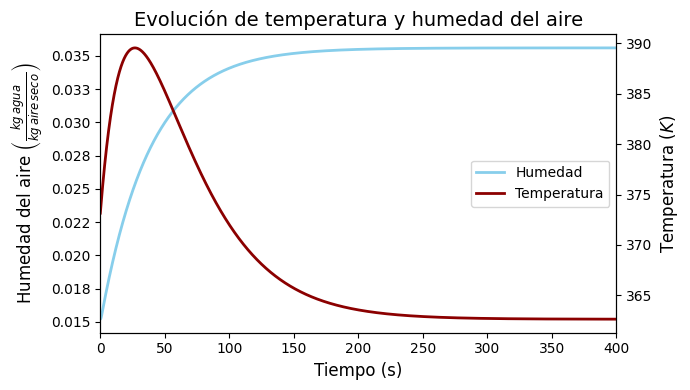

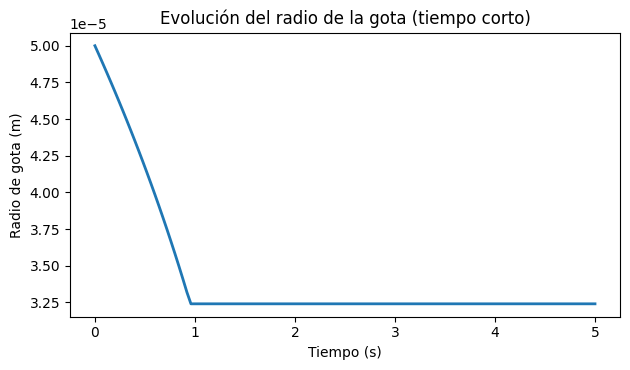

In [21]:
# --- Preámbulo Universal para Google Colab y Entornos Locales ---
import os, sys

if 'google.colab' in sys.modules:
    REPO_DIR = '/content/DAII-SprayDrying'
    if not os.path.exists(REPO_DIR):
        !git clone https://github.com/felipehuerta17/DAII-SprayDrying.git {REPO_DIR}
    os.chdir(REPO_DIR)
    if REPO_DIR not in sys.path:
        sys.path.insert(0, REPO_DIR)
    %pip install -q numpy scipy pandas matplotlib pymoo casadi


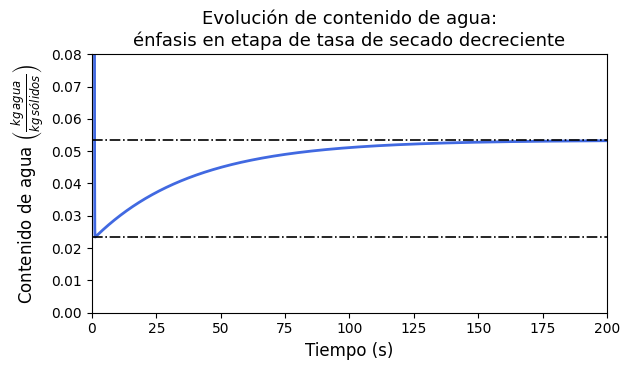

In [22]:
# Figura: evolución de contenido de agua
plt.figure(figsize=(6.4,3.8))
plt.plot(t, Xo, color='royalblue', linewidth=2)

# Límites de referencia (como en la figura adjunta)
plt.axhline(min(Xo), color='k', linestyle='-.', linewidth=1.2)
plt.axhline(Xo[-1], color='k', linestyle='-.', linewidth=1.2)

plt.xlabel('Tiempo (s)', fontsize=12)
plt.ylabel(r'Contenido de agua $\left(\frac{kg \, agua}{kg \, sólidos}\right)$', fontsize=12)
plt.title('Evolución de contenido de agua:\nénfasis en etapa de tasa de secado decreciente', fontsize=13)
plt.ylim([0, 0.08])
plt.xlim([0, 200])
plt.tight_layout()
plt.savefig('./outputs/evolucion_contenido_agua.svg', format='svg', dpi=300)
plt.show()


---
## 🔬 Exploración y Modificación del Modelo Fenomenológico (API v2.0)

Con la nueva estructura modular de `spraydrylib`, los estudiantes pueden modificar fácilmente los parámetros del modelo, agregar fenómenos como **pérdidas de calor en pared** y **radiación térmica**, o cambiar las correlaciones de transporte sin modificar el código interno.


In [ ]:
# 1. Configuración de condiciones de operación y parámetros del secador
from spraydrylib import SprayDryer, OperatingConditions, DryerParameters

# Condiciones operativas personalizadas
op = OperatingConditions(
    G=650 / 3600.0,    # Caudal de aire seco (kg/s)
    T_i=145 + 273.15,  # Temperatura de entrada del aire (K)
    ri=5.0e-5          # Radio inicial de gota (50 um)
)

# Parámetros del secador: agregamos pérdidas por pared (U_wall) y radiación térmica (emissivity)
params_dryer = DryerParameters(
    A_wall=15.0,        # Área de pared (m2)
    U_wall=5.0,         # Coeficiente global de pérdida en pared (W/m2/K) [0 = adiabático]
    emissivity=0.85,    # Emisividad de radiación térmica [0 = sin radiación]
    Nu=2.0              # Número de Nusselt para la gota
)

# Instanciar el secador y simular
dryer = SprayDryer(params=op, config=params_dryer)
res = dryer.simulate(tf=400.0, n_steps=600)

print(f"Temperatura final T4 con pérdidas: {res.T4[-1] - 273.15:.2f} °C")
print(f"Humedad final del sólido Xo: {res.Xo[-1]:.4f} kg agua / kg sólido")
print(f"Gasto energético: {res.get_energy_consumption_kw():.2f} kW")

# Visualización rápida de los 4 estados principales
res.plot()


### Comparación: Secador Adiabático vs Con Pérdidas de Calor y Radiación
Podemos comparar el impacto en la temperatura y cinética de secado al incorporar pérdidas térmicas:

In [ ]:
# Simulación adiabática (caso base)
dryer_adiab = SprayDryer(params=op, config=DryerParameters(U_wall=0.0, emissivity=0.0))
res_adiab = dryer_adiab.simulate(tf=400.0)

# Simulación con convección de pared (U_wall = 10 W/m2/K)
dryer_conv = SprayDryer(params=op, config=DryerParameters(U_wall=10.0, emissivity=0.0))
res_conv = dryer_conv.simulate(tf=400.0)

# Simulación con convección + radiación (U_wall = 10 W/m2/K, eps = 0.85)
dryer_rad = SprayDryer(params=op, config=DryerParameters(U_wall=10.0, emissivity=0.85))
res_rad = dryer_rad.simulate(tf=400.0)

# Graficar comparación de temperatura T4
plt.figure(figsize=(7.5, 4.2))
plt.plot(res_adiab.t, res_adiab.T4 - 273.15, label="Adiabático", lw=2)
plt.plot(res_conv.t, res_conv.T4 - 273.15, label="Pérdida Pared (U=10)", lw=2)
plt.plot(res_rad.t, res_rad.T4 - 273.15, label="Pared + Radiación (eps=0.85)", lw=2)
plt.xlabel("Tiempo (s)")
plt.ylabel("Temperatura del aire salida T4 (°C)")
plt.title("Impacto de las Pérdidas Térmicas en la Cámara de Secado")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
